# Módulo 3 - Prueba
## Análisis estadístico con Python
En este documento validaremos los conocimientos adquiridos durante este módulo.

La OMS estima que cada año se producen 12 millones de muertes en todo el mundo debido a enfermedades cardíacas, producidas en su gran mayoría por enfermedades cardiovasculares. El pronóstico temprano de las enfermedades cardiovasculares puede ayudar en la toma de decisiones sobre cambios en el estilo de vida en pacientes de alto riesgo y reducir las complicaciones. 

La base de datos cardio.csv contiene mediciones realizadas a pacientes hace 10 años. A partir de estos datos, buscaremos realizar algunas descripciones predictivas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats

np.random.seed(50)  # Para reproducibilidad

### Paso 1
Carga los datos y explóralos. Elimina los datos nulos o incorrectos.

In [2]:
df = pd.read_csv('cardio.csv')
df.head()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   object 
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(5), object(2)
memory usage: 529.9+ KB


Vemos que solo hay dos columnas no númericas, que corresponden al sexo y si es actualmente fumador o no.

In [4]:
display(df['sex'].value_counts())
display(df['currentSmoker'].value_counts())

sex
F    2419
M    1819
Name: count, dtype: int64

currentSmoker
No     2144
Yes    2094
Name: count, dtype: int64

Para el sexo, por el momento, hace sentido dejar la variable como categórica. En cambio, currentSmoker tiene el mismo principio que las otras variables numéricas; podemos asignar 0 si no es actualmente fumador, y 1 en caso de que lo sea.

In [5]:
# Transformar currentSmoker a variable numérica (no tiene valores nulos)
df['currentSmoker'] = df['currentSmoker'].map({'No': 0, 'Yes': 1})
display(df['currentSmoker'].value_counts())

# Sex como variable categórica
df['sex'] = df['sex'].astype('category')
display(df['sex'].value_counts())

currentSmoker
0    2144
1    2094
Name: count, dtype: int64

sex
F    2419
M    1819
Name: count, dtype: int64

In [6]:
# Ahora eliminemos los valores nulos en las columnas numéricas
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3656 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sex              3656 non-null   category
 1   age              3656 non-null   int64   
 2   education        3656 non-null   float64 
 3   currentSmoker    3656 non-null   int64   
 4   cigsPerDay       3656 non-null   float64 
 5   BPMeds           3656 non-null   float64 
 6   prevalentStroke  3656 non-null   int64   
 7   prevalentHyp     3656 non-null   int64   
 8   diabetes         3656 non-null   int64   
 9   totChol          3656 non-null   float64 
 10  sysBP            3656 non-null   float64 
 11  diaBP            3656 non-null   float64 
 12  BMI              3656 non-null   float64 
 13  heartRate        3656 non-null   float64 
 14  glucose          3656 non-null   float64 
 15  TenYearCHD       3656 non-null   int64   
dtypes: category(1), float64(9), int64(6)
memory usa

Al limpiar los nulos Nos quedamos con $3656$ registros de los $4238$ que teniamos en un principio. 

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3656.0,49.557440,8.561133,32.00,42.00,49.00,56.00,70.0
education,3656.0,1.979759,1.022657,1.00,1.00,2.00,3.00,4.0
currentSmoker,3656.0,0.489059,0.499949,0.00,0.00,0.00,1.00,1.0
cigsPerDay,3656.0,9.022155,11.918869,0.00,0.00,0.00,20.00,70.0
BPMeds,3656.0,0.030361,0.171602,0.00,0.00,0.00,0.00,1.0
prevalentStroke,3656.0,0.005744,0.075581,0.00,0.00,0.00,0.00,1.0
prevalentHyp,3656.0,0.311543,0.463187,0.00,0.00,0.00,1.00,1.0
diabetes,3656.0,0.027079,0.162335,0.00,0.00,0.00,0.00,1.0
totChol,3656.0,236.873085,44.096223,113.00,206.00,234.00,263.25,600.0
sysBP,3656.0,132.368025,22.092444,83.50,117.00,128.00,144.00,295.0


### Paso 2
Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas, utilizando indicadores y gráficos. ¿Cuál presenta mayor dispersión?
___

Escogemos nuestras variables cuantitativas: edad, cigarros por dia, y ritmo cardíaco 

,age,cigsPerDay,heartRate
mean,49.557440,9.022155,75.730580
median,49.000000,0.000000,75.000000
std,8.561133,11.918869,11.982952
min,32.000000,0.000000,44.000000
max,70.000000,70.000000,143.000000


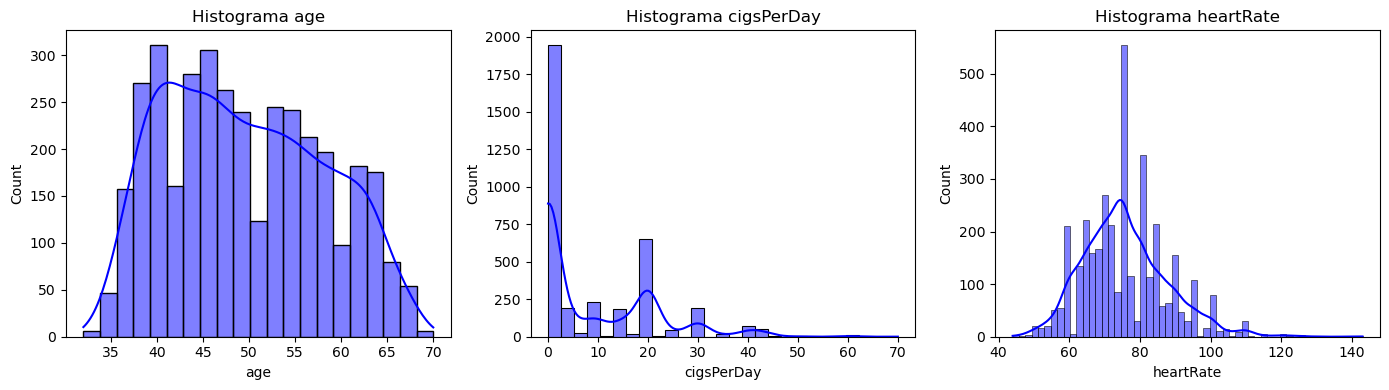

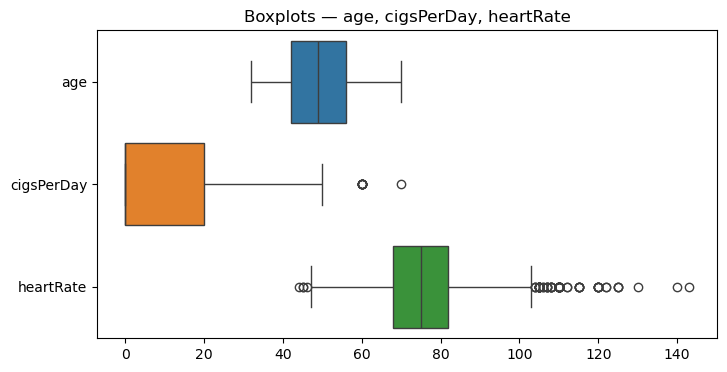

Desviación estándar (std):


heartRate     11.982952
cigsPerDay    11.918869
age            8.561133
Name: std, dtype: float64

In [8]:
# Calculamos estadísticas descriptivas y visualizamos las distribuciones
variables = ['age','cigsPerDay','heartRate']
resumen = df[variables].agg(['mean','median','std','min','max'])
display(resumen)

# Visualizaciones
fig, ax = plt.subplots(1, 3, figsize=(14,4))
# Histogramas
for i, col in enumerate(variables):
    sns.histplot(df[col], kde=True, ax=ax[i], color='blue')
    ax[i].set_title(f'Histograma {col}')
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(8,4))
sns.boxplot(data=df[variables], orient='h')
plt.title('Boxplots — age, cigsPerDay, heartRate')
plt.show()


dispersion = resumen.T['std'].sort_values(ascending=False)
print('Desviación estándar (std):')
display(dispersion)

Del gráfico boxplot observamos que tanto cigsPerDay como heartRate presentan alta dispersión y presencia de valores atípicos. 

Los valores de desviación estándar son similares, pero hay que considerar que los rangos de valores para estas variables son distintos. En particular, cigsPerDay es el que tiene un rango de valores más pequeño.

Para comprobar, normalizamos estos valores para ver cuál tiene mayor dispersión.

In [9]:
# Coeficiente de variación (CV) - Medida de dispersión relativa
cv = (df[variables].std() / df[variables].mean())
print('Coeficiente de variación (%):')
display(cv.sort_values(ascending=False))

Coeficiente de variación (%):


cigsPerDay    1.321067
age           0.172752
heartRate     0.158231
dtype: float64

Y en efecto, comprobamos que cigsPerDay es el que tiene mayor dispersión. Esto puede deberse a la presencia de los no fumadores en esta variable (cigsPerDay == $0$)

### Paso 3
Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el dataset "limpio".
___
Para eliminar los datos atípicos usaremos el método del rango intercuartílico utilizado en un desafío previo. Consideraremos solo las columnas que representan valores dentro de un continuo, en este caso:
- la edad
- nivel de colesterol total
- presión arterial sistólica
- presión arterial diastolica
- índice de masa corporal
- ritmo cardíaco
- nivel de glucosa

El resto son variables que representan un 'Si' o un 'No' respecto a una pregunta. La educación está codificada en 4 categorías, por lo que tampoco hace sentido. Por ultimo, los cigarros por día se podrían considerar pero habría que filtrar solo a los fumadores ya que la presencia de muchos $0's$ también es información relevante que no debería considerarse como outliers.


In [10]:
def remove_outliers_iqr(df, columns):
    # Esta vez lo aplicamos a múltiples columnas
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

cols_for_iqr = [
    'totChol', 'sysBP', 'diaBP',
    'BMI', 'heartRate', 'glucose'
]
df_clean = remove_outliers_iqr(df, cols_for_iqr)

print("Tamaño original sin nulos:", df.shape[0])
print("Tamaño después de eliminar outliers:", df_clean.shape[0])

Tamaño original sin nulos: 3656
Tamaño después de eliminar outliers: 3184


### Paso 4
¿Qué variables cuantitativas presentan mayor correlación? Explica
___
Crearemos gráficos y aplicaremos algunas funciones para buscar correlaciones entre las variables.

<Figure size 1000x600 with 0 Axes>

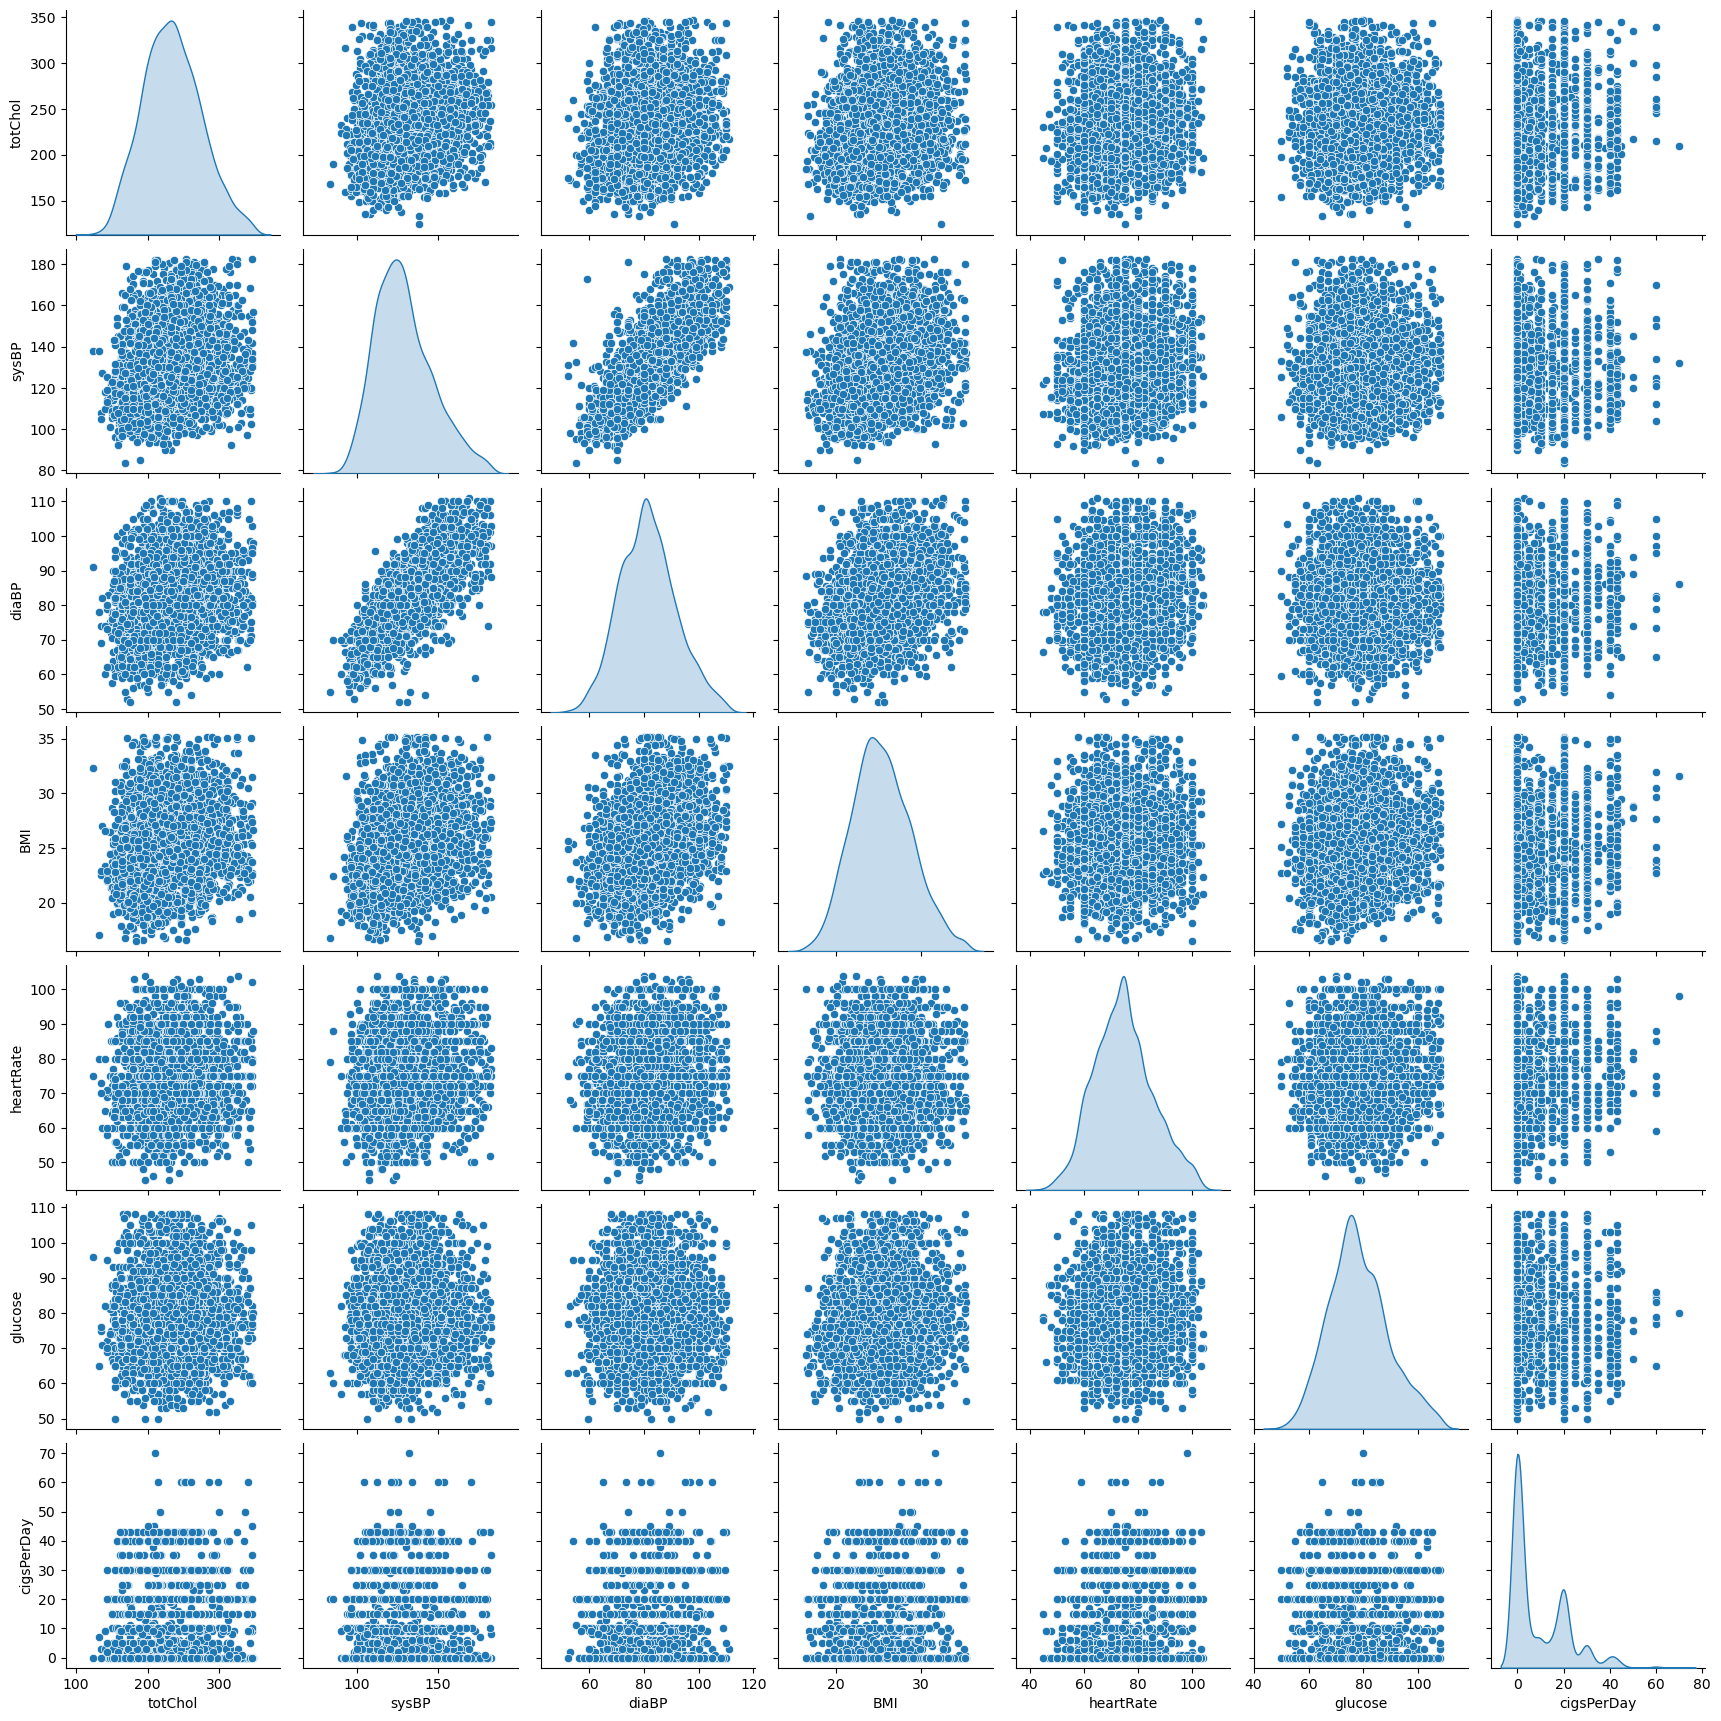

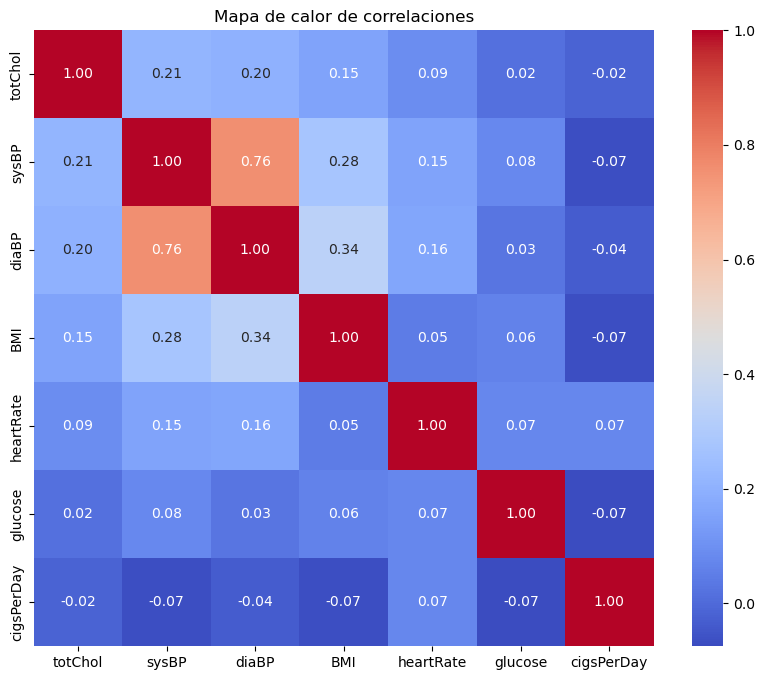

In [11]:
# Agregamos cigsPerDay para las columnas numéricas a revisar
numeric_cols = cols_for_iqr + ['cigsPerDay']

# Gráfico de pares (pairplot) para ver correlaciones
plt.figure(figsize=(10,6))
sns.pairplot(df_clean, vars=numeric_cols, diag_kind='kde')
plt.show()

# Mapa de calor de correlaciones
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Mapa de calor de correlaciones')
plt.show()


Podemos ver tanto en el gráfico de pairplot como en el heatmap, que de estos datos los únicos correlacionados son las presiones arteriales (sistólica y diastólica).

Ahora revisemos con las funciones de correlación

In [12]:
corr = df_clean[numeric_cols].corr()
display(corr)

,totChol,sysBP,diaBP,BMI,heartRate,glucose,cigsPerDay
totChol,1.000000,0.212254,0.201102,0.153828,0.092900,0.015808,-0.018004
sysBP,0.212254,1.000000,0.760388,0.275339,0.152824,0.077331,-0.067925
diaBP,0.201102,0.760388,1.000000,0.337868,0.161046,0.027133,-0.036834
BMI,0.153828,0.275339,0.337868,1.000000,0.045122,0.063307,-0.067022
heartRate,0.092900,0.152824,0.161046,0.045122,1.000000,0.073564,0.073712
glucose,0.015808,0.077331,0.027133,0.063307,0.073564,1.000000,-0.074735
cigsPerDay,-0.018004,-0.067925,-0.036834,-0.067022,0.073712,-0.074735,1.000000


Vemos el mismo resultado que en los gráficos; la correlación mas fuerte entre estos datos se da entre las presiones arteriales.
En comparación, el resto de variables visualmente se ven como un bloque de datos al graficarlas entre sí.

### Paso 5
Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que sea hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente al índice de masa corporal?
___
Para calcular esta probabilidad usaremos el teorema de Bayes:

$P(A|B) = \frac{P(AyB)}{P(B)}$

La probabilidad de que sea hombre dado que pertenece al mayor cuartil de indice de masa corporal es igual a la probabilidad de que sea hombre y pertenezca al mayor cuartil de indice de masa corporal dividido la probabilidad de que pertenezca al mayor cuartil de indice de masa corporal.

In [13]:
# Calculamos nuestras probabilidades
q75_bmi = df_clean['BMI'].quantile(0.75)
total = df_clean.shape[0]

p_q75_bmi = df_clean[df_clean['BMI'] > q75_bmi].shape[0] / total
p_male_and_q75_bmi = \
    df_clean[(df_clean['BMI'] > q75_bmi) & (df_clean['sex'] == 'M')].shape[0] / total

p_male_given_q75_bmi = p_male_and_q75_bmi / p_q75_bmi
print('--- Probabilidades ---')
print(f'Probabilidad de pertenecer al mayor cuartil de BMI: {p_q75_bmi:.4f}')
print(f'Probabilidad de ser hombre y pertenecer al mayor cuartil de BMI: {p_male_and_q75_bmi:.4f}')
print(f'Probabilidad de que sea hombre dado que pertenece al mayor cuartil de BMI: {p_male_given_q75_bmi:.4f}')


--- Probabilidades ---
Probabilidad de pertenecer al mayor cuartil de BMI: 0.2497
Probabilidad de ser hombre y pertenecer al mayor cuartil de BMI: 0.1347
Probabilidad de que sea hombre dado que pertenece al mayor cuartil de BMI: 0.5396


Por lo tanto, la probabilidad de que sea hombre dado que pertene al mayor cuartil de indide de masa corporal es del $53.9$%

### Paso 6
¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro del dataset), su ritmo cardiaco promedio es 75? Explica y justifica
___
Para esto realizaremos un test de hipótesis, donde nuestra hipótesis nula corresponde a que el promedio del ritmo cardiaco sea 75, mientras que la hipótesis alternativa será que sea distinto.

Dado que nos preguntan para una persona cualquiera, es decir de la población en general, consideraremos el dataset como nuestra muestra. 

Para el nivel de significancia, definiremos su valor como $\alpha = 0.05$. Con esto realizamos el siguiente cálculo:

In [14]:
x = df_clean['heartRate']
h_0 = 75  # Hipótesis nula
alpha = 0.05  # Nivel de significancia


def test_hipotesis(data, hipotesis):
    t_stat, p_value = stats.ttest_1samp(data, hipotesis)
    x_mean = np.mean(data)
    n = len(data)
    se = stats.sem(data)

    if p_value < alpha:
        resultado= "rechazamos la hipótesis nula"
    else:
        resultado= "aceptamos la hipótesis nula"

    ci = stats.t.interval(confidence=(1-alpha), df=n-1, loc=x_mean, scale=se)


    print('--- Test de Hipótesis ---')
    print(f'Estadístico t: {t_stat:.4f}')
    print(f'Valor p: {p_value:.4f}')
    print(f'Con nivel de confianza del {(1-alpha)*100}%, {resultado}.')
    print(f'El promedio del ritmo cardiaco en la muestra es {x_mean:.2f}, con hipótesis nula de {h_0}.')
    print(f'Intervalo de confianza del {(1-alpha)*100}%: {ci[0]:.2f} a {ci[1]:.2f}')

test_hipotesis(x, h_0)

--- Test de Hipótesis ---
Estadístico t: -2.3237
Valor p: 0.0202
Con nivel de confianza del 95.0%, rechazamos la hipótesis nula.
El promedio del ritmo cardiaco en la muestra es 74.56, con hipótesis nula de 75.
Intervalo de confianza del 95.0%: 74.19 a 74.93


En este caso hemos rechazado el test de hipótesis, lo que está bien en el sentido de que el promedio del dataset es de $74.56$ que, en efecto, es distinto de $75$.

Pero también es razonable afirmar que la diferencia entre el promedio del dataset y la hipotesis es lo suficientemente pequeña (o que estan lo suficientemente cerca) como para rechazarla. 

Si hacemos el cálculo con un nivel de significancia menor (en particular, $\alpha < p$), aceptariamos la hipótesis nula.


In [15]:
alpha = 0.02
test_hipotesis(x, h_0)

--- Test de Hipótesis ---
Estadístico t: -2.3237
Valor p: 0.0202
Con nivel de confianza del 98.0%, aceptamos la hipótesis nula.
El promedio del ritmo cardiaco en la muestra es 74.56, con hipótesis nula de 75.
Intervalo de confianza del 98.0%: 74.12 a 75.00


### Paso 7
Ser hombre, ¿influye en el promedio de cigarrillos consumidos por dia, dentro de los pacientes fumadores? Explica.
___
Primero vamos a filtrar y agrupar nuestros datos para revisarlos

,mean,median,std,count
sex,,,,
F,13.997147,15.0,8.661243,701
M,22.353741,20.0,10.956608,882


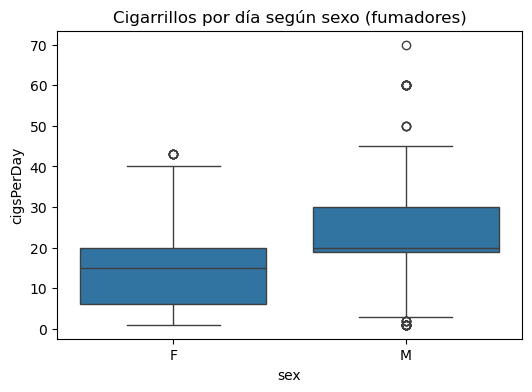

In [16]:
smokers = df_clean[df_clean['currentSmoker'] == 1]
grouped = smokers.groupby('sex', observed=True)['cigsPerDay'].agg(['mean','median','std','count'])
display(grouped)

plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='cigsPerDay', data=smokers)
plt.title('Cigarrillos por día según sexo (fumadores)')
plt.show()

Vemos que:
- Hay mas hombres que mujeres fumadores
- El promedio y media diario de cigarrillos es mayor en hombres
- Hay mas dispersión en los datos de varones, asi como outliers

Ahora realizaremos un test t de muestras independientes donde los grupos corresponden a hombres y mujeres fumadores. Nuestra hipótesis nula corresponde a que el promedio de cigarrillos por dia es igual para hombres y mujeres:

In [17]:
smokers_males = smokers[smokers['sex'] == 'M']
smokers_females = smokers[smokers['sex'] == 'F']

# Prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(\
        smokers_males['cigsPerDay'],\
        smokers_females['cigsPerDay'],\
        equal_var=False)
alpha = 0.05

if p_value < alpha:
    resultado= f"Rechazamos la hipótesis nula, \nya que el promedio de cigarrilos diarios por hombres:\n {smokers_males['cigsPerDay'].mean():.2f} \nes distinto al promedio por mujeres:\n {smokers_females['cigsPerDay'].mean():.2f}"
else:
    resultado= "Aceptamos la hipótesis nula. No hay suficiente evidencia para rechazarla."

print('--- Test de Hipótesis para cigarrillos por día según sexo ---')
print(f'H₀: μ_hombres = μ_mujeres')
print(f'H₁: μ_hombres ≠ μ_mujeres')
print(f'α = {alpha}')
print(f'Estadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.4f}')

print(f'Resultado: {resultado}')

--- Test de Hipótesis para cigarrillos por día según sexo ---
H₀: μ_hombres = μ_mujeres
H₁: μ_hombres ≠ μ_mujeres
α = 0.05
Estadístico t: 16.9479
Valor p: 0.0000
Resultado: Rechazamos la hipótesis nula, 
ya que el promedio de cigarrilos diarios por hombres:
 22.35 
es distinto al promedio por mujeres:
 14.00


Rechazada la hipótesis nula, corroboramos que ser hombre **SI** influye en la cantidad de cigarrillos por dia.

### Paso 8
Construye un modelo de regresión lineal que permita relacionar 6 variables del dataset con el índice de masa corporal. (Debes incluir al menos dos variables cualitativas). Evalúa tu modelo y explica.

In [18]:
# Nuestras variables cualitativas son si es fumador o no, y si es o no hipertenso
X_multi = df[['age','totChol','heartRate','glucose', 'currentSmoker', 'prevalentHyp']]
y = df['BMI']

X_multi = sm.add_constant(X_multi)
model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary2())

# Predicciones
y_pred_multi = model_multi.predict(X_multi)

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.114     
Dependent Variable: BMI              AIC:                20193.8635
Date:               2025-10-31 20:10 BIC:                20237.2924
No. Observations:   3656             Log-Likelihood:     -10090.   
Df Model:           6                F-statistic:        79.75     
Df Residuals:       3649             Prob (F-statistic): 5.19e-94  
R-squared:          0.116            Scale:              14.639    
--------------------------------------------------------------------
                 Coef.   Std.Err.     t     P>|t|    [0.025   0.975]
--------------------------------------------------------------------
const           22.5905    0.6339  35.6370  0.0000  21.3476  23.8333
age              0.0029    0.0082   0.3602  0.7187  -0.0131   0.0190
totChol          0.0058    0.0015   3.8500  0.0001   0.0028   0.0087
heartRate        0.0105    0.0054   1.9370  0.0528  -0.0001 

De la tabla vemos lo siguiente:
- $r^2 = 11.6$%, esto nos dice que su poder de predicción es bajo
- $F$ estadístico $=79.75$, y $p$ del orden de magnitud $10^(-94)$, nos dice que hay aporte de ciertas variables a la señal estadística.
- Para las variables, en general las variables numéricas no tienen un aporte tan grande al modelo, pero las variables categóricas si (en este caso ser fumador y tener hipertensión); ser fumador negativamente, e hipertensión positivamente.

Lo que podemos apreciar en el siguiente gráfico:

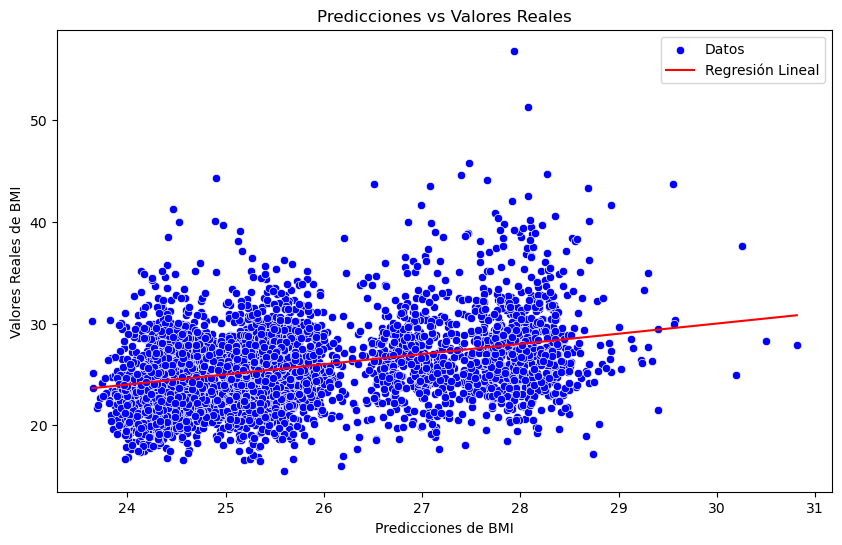

In [19]:
# Graficamos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_multi, y=y, color='blue', label='Datos')
plt.plot([y_pred_multi.min(), y_pred_multi.max()], [y_pred_multi.min(), y_pred_multi.max()], color='red', label='Regresión Lineal')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Predicciones de BMI')
plt.ylabel('Valores Reales de BMI')
plt.legend()
plt.show()

Vemos que la regresión pasa por los datos, pero estos se encuentran tan dispersos en el plano que en realidad no hay un modelo de regresión lineal que tenga un poder predictivo muy alto para estos datos.

### Paso 9
Construye un modelo de regresión logística para predecir el riesgo de sufrir una enfermedad coronaria en los próximos diez años, a partir de las variables descritas. Verifica el balanceo de datos y evalúa tu modelo.

### Paso 10
Separa los modelos de regresión anteriores en dos distintos, respectivamente, considerando alguna variable categórica. Compara y concluye.